<a href="https://colab.research.google.com/github/zuhaatawakal-create/AI-/blob/main/Q2_1_(c).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/housing.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
# Display information about the DataFrame to see column types and non-null counts
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


None

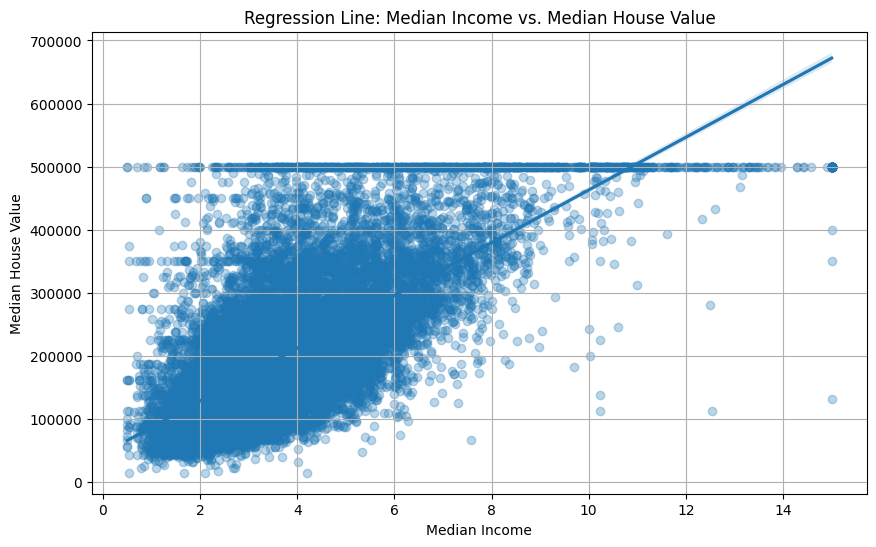

In [ ]:
# Fill missing values in 'total_bedrooms' and 'population' with the mean
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].mean())
df['population'] = df['population'].fillna(df['population'].mean())

# Create a regression plot
plt.figure(figsize=(10, 6))
sns.regplot(x='median_income', y='median_house_value', data=df, scatter_kws={'alpha':0.3})
plt.title('Regression Line: Median Income vs. Median House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define features (X) and target (y)
# We'll drop 'ocean_proximity' for this simple linear regression as it's categorical
# and we need to predict 'median_house_value'.
X = df.drop(['median_house_value', 'ocean_proximity'], axis=1)
y = df['median_house_value']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model (optional, but good practice)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared: {r2:.2f}')

Mean Squared Error: 5052953703.90
R-squared: 0.61


Now, let's visualize the actual versus predicted values. A good model would have predictions that fall closely along the diagonal line.

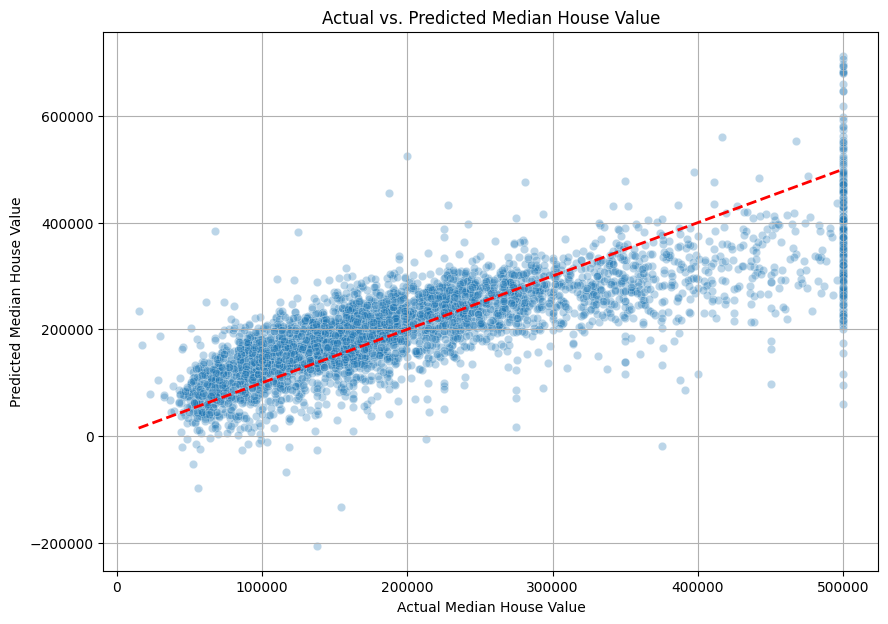

In [ ]:
# Create a scatter plot of Actual vs. Predicted values
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal line
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.title('Actual vs. Predicted Median House Value')
plt.grid(True)
plt.show()

We can also look at the residuals (the differences between actual and predicted values) to check for patterns. Ideally, residuals should be randomly scattered around zero.

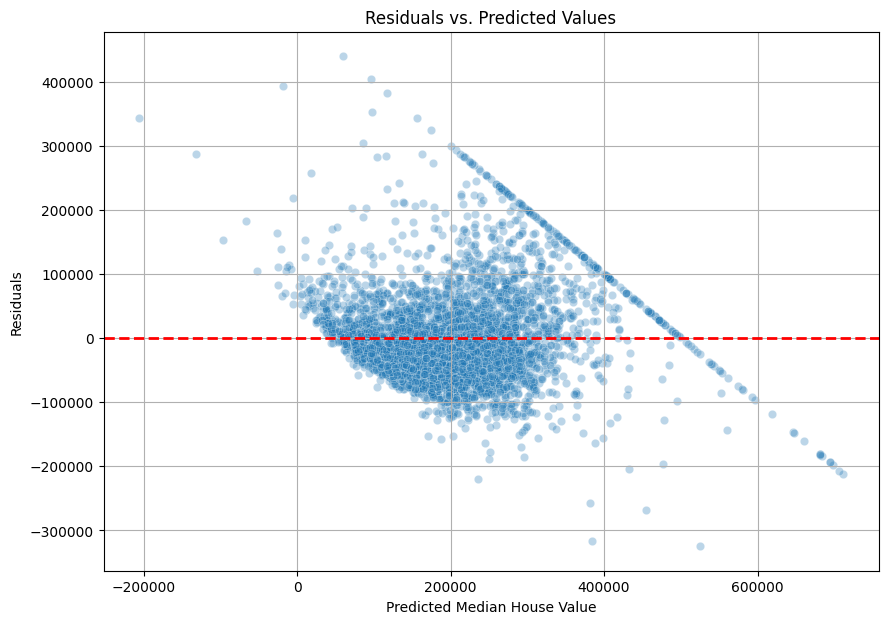

In [ ]:
# Plotting Residuals
residuals = y_test - y_pred

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Median House Value')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Values')
plt.grid(True)
plt.show()

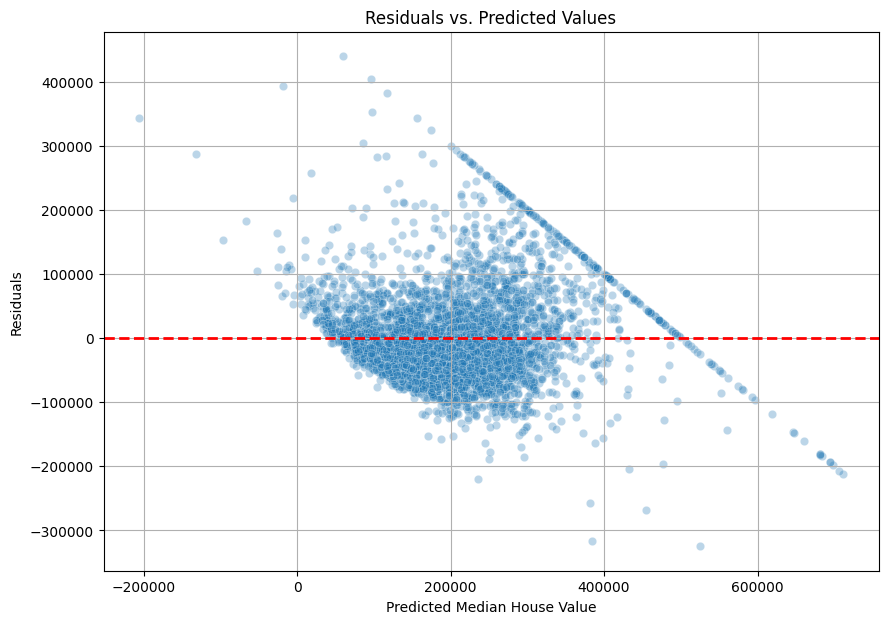

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Median House Value')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Values')
plt.grid(True)
plt.show()

## Interpretation of Model Results

### Model Performance Metrics

*   **Mean Squared Error (MSE):** `5052953703.90`
    *   MSE represents the average of the squared differences between the actual and predicted values. A lower MSE indicates a better fit of the model to the data. This value is quite large, suggesting that the model's predictions have a significant average squared error, which might be due to the scale of the `median_house_value` or limitations of a simple linear model for this dataset.

*   **R-squared (R²):** `0.61`
    *   R-squared is a statistical measure that represents the proportion of the variance in the dependent variable (median house value) that can be explained by the independent variables (features) in the linear regression model. An R-squared of 0.61 means that approximately 61% of the variance in median house value can be explained by the features included in our model. This is a moderately good fit, but there is still 39% of the variance that the model does not explain, suggesting there might be other important factors or non-linear relationships not captured by this simple linear model.

### Visualizations

*   **Actual vs. Predicted Median House Value Plot:**
    *   In an ideal scenario, the scattered points would lie perfectly along the red diagonal line, indicating that the predicted values exactly match the actual values. Our plot shows that while there's a general trend of points clustering around the diagonal line, especially for lower house values, there's significant scatter. This indicates that the model is making reasonably accurate predictions for some houses but struggles with others. The spread of points around the line suggests that the model's predictions are not perfectly precise. The upper bound of `median_house_value` at 500,000 for many instances is clearly visible as a horizontal line of points on the plot, indicating a capping of the target variable in the original dataset.

*   **Residuals vs. Predicted Values Plot:**
    *   Ideally, the residuals (the differences between actual and predicted values) should be randomly scattered around zero, with no discernible pattern. Our residuals plot shows a few key observations:
        *   **Heteroscedasticity:** The spread of residuals is not constant across all predicted values. We see a wider spread for higher predicted values, indicating that the model's errors tend to be larger for more expensive houses. This is a common issue and suggests that the model might not be equally good at predicting values across the entire range.
        *   **Pattern:** There appears to be a triangular or fan-like shape in the residuals, where the spread increases as predicted values increase. This is a strong indicator of heteroscedasticity and suggests that the assumption of constant variance of errors (homoscedasticity) in linear regression is violated. The capping of the `median_house_value` is also evident here, as the residuals are negatively skewed for higher predicted values.
        *   **Bias:** While the residuals are centered around zero on average, the pattern suggests potential issues with the model's assumptions or that important variables are missing, particularly for higher-valued homes. The strong diagonal line of points in the upper right corner of the plot indicates that the model is under-predicting for these houses, often predicting values much lower than their actual value, up to the maximum capped value.

### Conclusion

The linear regression model provides a moderate fit to the data, explaining 61% of the variance in median house values. However, the high MSE and patterns observed in the residuals plot (especially heteroscedasticity and the influence of the capped `median_house_value`) indicate that a simple linear model might not be sufficient. Further improvements could involve:

1.  **Feature Engineering:** Creating new features or transforming existing ones (e.g., polynomial features, interaction terms).
2.  **Handling Categorical Features:** Encoding 'ocean_proximity' using one-hot encoding or other methods.
3.  **Advanced Models:** Exploring more complex models like Random Forests, Gradient Boosting, or Neural Networks that can capture non-linear relationships and handle heteroscedasticity better.
4.  **Addressing Data Capping:** Investigating the impact of the capped `median_house_value` at \$500,000 and considering alternative modeling approaches if this is a significant issue.